# GraphRAG Pipeline — Code Summary

## What It Does

Builds an AI-powered knowledge graph from a CSV of unicorn startup companies.
Uses a local LLM (Mistral) to extract relationships, organizes them into a graph,
detects communities, and answers natural language questions using graph-based retrieval.

---

## Pipeline Flow

```
CSV → Text → Triple Extraction → Deduplication → Knowledge Graph
                                                        │
                                          ┌─────────────┴─────────────┐
                                       CLUSTERING                  QUERYING
                                          │                            │
                                   Community Detection          Entity Detection
                                          │                            │
                                   Cluster Summaries           Graph Traversal
                                          │                            │
                                   Global Summary               LLM Answer
```

---

## Steps

### Step 1 — Load & Sample
- Reads `Unicorn_Companies.csv`
- Selects 6 columns: Company, Valuation, Industry, City, Founded Year, Investors
- Drops nulls, samples 30 rows for POC

### Step 2 — Row to Text
- Converts each row into a natural language sentence
- Example: *"Stripe is a company in the Fintech industry, located in San Francisco..."*
- Prepares structured data for LLM consumption

### Step 3 — LLM Setup
- Initializes **Mistral** locally via `OllamaLLM`
- `temperature=0` for deterministic, consistent outputs

### Step 4 & 5 — Triple Extraction
- Prompts the LLM for each sentence to extract triples in format:
  ```
  Entity1 | Relation | Entity2
  ```
- Parses LLM response line by line into `(head, relation, tail)` tuples
- Collects all triples into `all_triples[]`

### Step 6 — Entity Deduplication ⭐
Two functions work together to clean inconsistent LLM output:

**`normalize_entity()`**
- Strips whitespace and quote characters
- Lowercases then title-cases for consistent casing
- Replaces underscores with spaces
- Fixes surface-level inconsistencies like `"accel"` vs `"Accel"`

**`deduplicate_entities()`**
- Collects all unique entity names across all triples
- Fuzzy clusters similar names using `token_sort_ratio` (threshold: 85%)
  - `token_sort_ratio` sorts words alphabetically before comparing, so word-order variants like `"Accel Partners"` vs `"Partners Accel"` score 100%
- Picks the **longest name** in each cluster as the canonical name
- Rewrites all triples using canonical names
- Drops self-loops created by merging

> **Why this matters:** Without dedup, `"Accel"`, `"Accel Partners"`, and `"accel"` become 3 isolated nodes. After dedup, they merge into one well-connected node.

### Step 7 — Build Knowledge Graph
- Builds a **directed graph** (`nx.DiGraph`) from cleaned triples
- Nodes = entities (companies, investors, cities, industries)
- Edges = labeled relationships between entities
- Direction encodes meaning: `Accel → invested_in → Stripe` ≠ `Stripe → invested_in → Accel`

---

## Two Parallel Paths After Graph Build

### Clustering Path (runs once at startup)

#### Step 8 — Community Detection
- Converts DiGraph → undirected graph
  - Louvain only supports undirected (asks *"do nodes connect?"* not *"who points to whom?"*)
- Runs **Louvain algorithm** to group nodes into communities
- Each community = cluster of closely related entities

#### Step 9 — Cluster Summarization
- For each community, extracts all internal edges and relation labels
- Prompts LLM to write a 2–3 sentence summary of the cluster
- Produces human-readable descriptions of each group

#### Step 10 — Global Summary
- Combines all cluster summaries into one prompt
- LLM generates a single high-level overview of the entire startup ecosystem
- This is the **hierarchical layer** — insight at multiple levels of granularity

---

### Query Path (runs on demand per question)

#### Step 11 — Graph Traversal (`global_reasoning`)
- Takes a query entity and hop count (default: 2)
- Runs **BFS** on the DiGraph up to N hops from the entity
- Collects all edges within that subgraph as context
- Falls back to undirected traversal if no edges found (isolated node safety net)

#### Step 12 — Entity Detection (`detect_entity`)
Finds the most relevant graph node for a user's question:
1. **Fuzzy match** question text against all node names (score > 70 → use it)
2. **LLM fallback** — ask LLM to pick the best node from a sample list
3. **Validate** LLM output exists in graph
4. **Fuzzy match** LLM output against real nodes as final fallback

#### Step 13 — GraphRAG Query (`graphrag_query`)
Combines all query steps end to end:
1. `detect_entity()` → find the right node
2. `global_reasoning()` → retrieve subgraph context
3. `ask_llm()` → answer using **only** retrieved graph relationships

---

## Key Design Decisions

| Decision | Reason |
|---|---|
| DiGraph for knowledge graph | Direction encodes relationship meaning |
| Undirected for community detection | Louvain requires undirected; clustering only needs connectivity |
| `token_sort_ratio` for fuzzy matching | Handles word-order variants from LLM (`"Accel Partners"` vs `"Partners Accel"`) |
| Longest name as canonical | More descriptive names carry more context |
| Fuzzy match before LLM in entity detection | Faster and more reliable than LLM for exact/near-exact node names |
| Undirected fallback in traversal | Prevents silent failures when directed edges are missing |

---

## Libraries

| Library | Purpose |
|---|---|
| `pandas` | Data loading and preprocessing |
| `networkx` | Graph construction, traversal, and BFS |
| `langchain-ollama` | Interface with local Mistral LLM |
| `python-louvain` | Louvain community detection |
| `rapidfuzz` | Fuzzy string matching for deduplication and entity detection |
| `pydantic` | Structured output parsing from LLM |

---

## Limitations (POC)

- **In-memory only** — graph is rebuilt from scratch every run, no persistence
- **No vector DB** — retrieval is graph traversal only, no semantic similarity search
- **30 company sample** — increase `.sample()` to scale up
- **Triple quality** — depends entirely on LLM consistency; prompt tuning can improve this

---

## To Scale This Up

| Bottleneck | Solution |
|---|---|
| In-memory graph | Replace NetworkX with **Neo4j** |
| No semantic search | Add **Qdrant** or **Weaviate** over node embeddings |
| LLM triple quality | Fine-tune extraction prompt or use a larger model |
| Slow LLM calls | Batch extraction or switch to a faster model |

In [1]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import community as community_louvain
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field, field_validator
from rapidfuzz import process, fuzz
from typing import Any

In [2]:
########################################
# 1. Load Dataset
########################################
df = pd.read_csv("Unicorn_Companies.csv", low_memory=False)

cols = [
    "Company",
    "Valuation ($B)",
    "Industry",
    "City",
    "Founded Year",
    "Select Inverstors"
]
df.columns = df.columns.str.strip()
df = df[cols]
df = df.dropna()

# Small sample for POC
df = df.sample(30, random_state=42)
print("Rows:", len(df))

Rows: 30


In [3]:
########################################
# 2. Convert Rows to Text
########################################
def row_to_text(row):
    return (
        f"{row['Company']} is a company in the {row['Industry']} industry. "
        f"The company is located in {row['City']}. "
        f"It was founded in {int(row['Founded Year'])}. "
        f"The company is valued at {row['Valuation ($B)']} billion dollars. "
        f"Major investors include {row['Select Inverstors']}."
    )

texts = df.apply(row_to_text, axis=1).tolist()

In [5]:
########################################
# 3. Setup Ollama LLM
########################################
llm = OllamaLLM(model="mistral", temperature=0)


########################################
# 4. Triple Extraction
########################################
triple_prompt = PromptTemplate.from_template("""
Extract knowledge graph triples from the text.
Return one triple per line in this format:
Entity1 | Relation | Entity2

Text:
{text}
""")

def extract_triples(text):
    prompt = triple_prompt.format(text=text)
    response = llm.invoke(prompt)
    triples = []
    for line in response.split("\n"):
        parts = line.split("|")
        if len(parts) == 3:
            triples.append((
                parts[0].strip(),
                parts[1].strip(),
                parts[2].strip()
            ))
    return triples


In [6]:
########################################
# 5. Extract All Triples
########################################
all_triples = []
for t in texts:
    triples = extract_triples(t)
    all_triples.extend(triples)
print("Triples extracted:", len(all_triples))

Triples extracted: 199


In [7]:
########################################
# 6. Entity Deduplication
########################################
def normalize_entity(entity):
    """Basic text normalization for consistent matching."""
    entity = entity.strip().strip('"').strip("'")
    entity = entity.lower()
    entity = entity.replace("_", " ")
    return entity.title()

def deduplicate_entities(triples, threshold=85):
    """
    Merge entity names that are fuzzy-similar above the threshold.
    Returns cleaned triples with canonical entity names.
    """
    # Step 1: Collect all unique entities
    all_entities = set()
    for h, r, t in triples:
        all_entities.add(normalize_entity(h))
        all_entities.add(normalize_entity(t))

    all_entities = list(all_entities)

    # Step 2: Build a mapping from variant -> canonical name
    canonical_map = {}
    visited = set()

    for entity in all_entities:
        if entity in visited:
            continue

        # Find all similar entities
        matches = process.extract(
            entity,
            all_entities,
            scorer=fuzz.token_sort_ratio,  # handles word-order variants
            limit=None
        )

        similar = [m[0] for m in matches if m[1] >= threshold and m[0] != entity]

        # Pick canonical name: longest (most descriptive)
        cluster = [entity] + similar
        canonical = max(cluster, key=len)

        for variant in cluster:
            canonical_map[variant] = canonical
            visited.add(variant)

    # Step 3: Rewrite triples using canonical names
    cleaned_triples = []
    for h, r, t in triples:
        h_canon = canonical_map.get(normalize_entity(h), normalize_entity(h))
        t_canon = canonical_map.get(normalize_entity(t), normalize_entity(t))

        # Skip self-loops created by merging
        if h_canon == t_canon:
            continue

        cleaned_triples.append((h_canon, r, t_canon))

    return cleaned_triples, canonical_map


print(f"\nTriples before deduplication: {len(all_triples)}")
all_triples, entity_map = deduplicate_entities(all_triples, threshold=85)
print(f"Triples after deduplication:  {len(all_triples)}")

# Inspect sample merges
print("\nSample entity merges:")
seen = set()
for variant, canon in entity_map.items():
    if variant != canon and canon not in seen:
        print(f"  '{variant}' -> '{canon}'")
        seen.add(canon)


Triples before deduplication: 199
Triples after deduplication:  199

Sample entity merges:
  '5. Blockdaemon' -> '3. Blockdaemon'
  '$1.5 Billion Dollars' -> '$1.05 Billion Dollars'
  'D1 Capital Partners' -> 'Idg Capital Partners'
  '2. Miaoshou Doctor' -> '3. Miaoshou Doctor'
  '3. Away' -> '4. Away'
  'Sequoia Capital China' -> 'Sequoia Capital India'


In [8]:
########################################
# 7. Build Knowledge Graph
########################################
G = nx.DiGraph()
for head, rel, tail in all_triples:
    G.add_edge(head, tail, relation=rel)

print("\nNodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Diagnostic: check for isolated nodes
isolated = list(nx.isolates(G))
print(f"Isolated nodes (no edges): {len(isolated)}")

# Sample edges
print("\nSample edges:")
for u, v, d in list(G.edges(data=True))[:10]:
    print(f"  {u} | {d.get('relation')} | {v}")


Nodes: 142
Edges: 199
Isolated nodes (no edges): 0

Sample edges:
  Sharechat | is a company in the | Internet Software & Services Industry
  Sharechat | is located in | Bengaluru
  Sharechat | was founded in | 2015
  Sharechat | is valued at | $1.05 Billion Dollars
  Sharechat | Major investors include | India Quotient
  Sharechat | Major investors include | Elevation Capital
  Sharechat | Major investors include | Lightspeed Venture Partners
  Pointclickcare | is a company in the | Internet Software & Services Industry
  Pointclickcare | is located in | Mississauga
  Pointclickcare | was founded in | 2000


In [9]:
########################################
# 8. Community Detection
########################################
undirected = G.to_undirected()
partition = community_louvain.best_partition(undirected)
communities = defaultdict(list)
for node, cid in partition.items():
    communities[cid].append(node)
print("\nCommunities:", len(communities))


Communities: 12


In [10]:
########################################
# 9. Summarize Each Community
########################################
def summarize_cluster(nodes):
    subgraph = G.subgraph(nodes)
    relations = []
    for u, v, data in subgraph.edges(data=True):
        relations.append(f"{u} {data['relation']} {v}")
    context = "\n".join(relations)
    prompt = f"""
Summarize the following relationships in 2-3 sentences.
{context}
"""
    return llm.invoke(prompt)

cluster_summaries = {}
for cid, nodes in communities.items():
    summary = summarize_cluster(nodes)
    cluster_summaries[cid] = summary
    print(f"\nCluster {cid}")
    print(summary)


Cluster 7
 Pointclickcare is a software and services company founded in 2000, located in Mississauga, with major investors including Dragoneer Investment Group, Hellman & Friedman, and Jmi Equity.

Mixpanel is a software and services company founded in 2009, with major investors including Bain Capital Tech Opportunities, Andreessen Horowitz, and Sequoia Capital.

Sharechat is a software and services company located in Bengaluru, with major investors including India Quotient and Elevation Capital. All three companies operate within the Internet Software & Services Industry.

Cluster 0
 1. Away is a New York-based e-commerce company founded in 2015, operating within the E-Commerce & Direct-To-Consumer Industry.
2. Womai, an e-commerce company located in Beijing, has major investors including Saif Partners China, Baidu, and Idg Capital.
3. Miaoshou Doctor, an e-commerce company based in Beijing, was founded in 2015. It has major investors such as Sequoia Capital India and Qiming Venture 

In [11]:
########################################
# 10. Global Summary (Hierarchical Layer)
########################################
all_cluster_text = "\n".join(cluster_summaries.values())
global_prompt = f"""
Provide a high level summary of the startup ecosystem
based on these cluster summaries.
{all_cluster_text}
"""
global_summary = llm.invoke(global_prompt)
print("\nGLOBAL SUMMARY")
print(global_summary)


GLOBAL SUMMARY
 The provided data outlines various startups across different industries, primarily Internet Software & Services, E-Commerce & Direct-To-Consumer, Fintech, AI, Cybersecurity, Edtech, Supply Chain, Logistics, & Delivery, and Data Management & Analytics.

1. Internet Software & Services: Pointclickcare, Mixpanel, and Sharechat are software and services companies with major investors. Pointclickcare is based in Mississauga, Mixpanel in San Francisco, and Sharechat in Bengaluru.

2. E-Commerce & Direct-To-Consumer: Away, Womai, and Miaoshou Doctor are e-commerce companies with major investors. Away is based in New York, Womai in Beijing, and Miaoshou Doctor in Beijing.

3. Fintech: Blockdaemon, Collective Health, Mollie, Drivewealth, and Dream11 are Fintech companies with major investors. Blockdaemon is based in Los Angeles, Collective Health in Redwood City, Mollie in Amsterdam, Drivewealth in Chatham, and Dream11 in Mumbai.

4. AI: Veriff, Tenstorrent, Bloomreach, Groq, a

In [13]:
########################################
# 11. Graph Reasoning + Retrieval
########################################
def global_reasoning(graph, query_entity, hops=2):
    """Retrieve subgraph context within N hops of a query entity."""
    try:
        nodes = nx.single_source_shortest_path_length(graph, query_entity, cutoff=hops)
        sub_nodes = list(nodes.keys())
    except nx.NodeNotFound:
        print(f"Entity '{query_entity}' not found in graph.")
        return []

    print("Nodes involved in reasoning:")
    print(sub_nodes)

    context = []
    for u, v, data in graph.edges(data=True):
        if u in sub_nodes and v in sub_nodes:
            relation = data.get("relation", "related_to")
            context.append(f"{u} | {relation} | {v}")

    # Fallback: try undirected traversal if no edges found
    if not context:
        print("⚠️ No edges found in directed traversal. Trying undirected fallback...")
        undirected = graph.to_undirected()
        nodes = nx.single_source_shortest_path_length(undirected, query_entity, cutoff=hops)
        sub_nodes = list(nodes.keys())
        for u, v, data in graph.edges(data=True):
            if u in sub_nodes or v in sub_nodes:
                context.append(f"{u} | {data.get('relation', 'related_to')} | {v}")

    print("\nRetrieved Graph Relationships:")
    for c in context:
        print(" ", c)

    return context


def ask_llm(context, question):
    """Answer a question using only the retrieved graph context."""
    if not context:
        return "No graph context found to answer the question."

    context_text = "\n".join(context)
    prompt = f"""
You are analyzing a startup knowledge graph.

Graph Relationships:
{context_text}

Question:
{question}

Answer using only the graph relationships above.
"""
    return llm.invoke(prompt)


In [14]:
########################################
# 12. Entity Detection (Fuzzy + LLM)
########################################
class EntityOutput(BaseModel):
    entity: str = Field(description="Single node from the knowledge graph")

    @field_validator("entity", mode="before")
    def convert_list_to_string(cls, v: Any):
        if isinstance(v, list):
            return v[0]
        return v

parser = PydanticOutputParser(pydantic_object=EntityOutput)


def detect_entity(question, graph):
    """Fuzzy match first, fall back to LLM if needed."""
    nodes = list(graph.nodes())
    question_lower = question.lower()

    # Step 1: Fuzzy match question against node names
    match, score, _ = process.extractOne(
        question_lower,
        nodes,
        scorer=fuzz.token_sort_ratio,
        processor=lambda x: x.lower()
    )
    if score > 70:
        print(f"Fuzzy matched entity: '{match}' (score: {score})")
        return match

    # Step 2: Fall back to LLM with a sample of nodes
    node_sample = nodes[:50]
    format_instructions = parser.get_format_instructions()
    prompt = f"""
You are given a knowledge graph.

Graph Nodes:
{node_sample}

Question: {question}

Select the SINGLE node that best matches the question.
{format_instructions}
"""
    response = llm.invoke(prompt)
    try:
        parsed = parser.parse(response)
        candidate = parsed.entity.strip()
    except Exception:
        candidate = response.strip().strip('"').strip("'")

    # Step 3: Validate exact match
    if candidate in graph.nodes:
        return candidate

    # Step 4: Fuzzy match the LLM's output against real nodes
    match, score, _ = process.extractOne(
        candidate,
        nodes,
        scorer=fuzz.token_sort_ratio,
        processor=lambda x: x.lower()
    )
    return match if score > 60 else None


In [15]:
########################################
# 13. Full GraphRAG Query Function
########################################
def graphrag_query(graph, question, hops=2):
    print("\n" + "="*50)
    print("User Question:", question)

    entity = detect_entity(question, graph)
    print("Detected Entity:", entity)

    if entity is None:
        return "No matching entity found in graph."

    print(f"Node degree: {graph.degree(entity)}")

    context = global_reasoning(graph, entity, hops)
    answer = ask_llm(context, question)
    return answer


In [16]:
########################################
# 14. Run Example Queries
########################################
questions = [
    "Which investors funded AI companies?",
    "What industries are most common among unicorns?",
    "Which cities have the most unicorn startups?",
]

for q in questions:
    answer = graphrag_query(G, q)
    print("\nFinal Answer:\n", answer)
    print("="*50)


User Question: Which investors funded AI companies?
Detected Entity: Lightspeed Venture Partners
Node degree: 2
Nodes involved in reasoning:
['Lightspeed Venture Partners']
⚠️ No edges found in directed traversal. Trying undirected fallback...

Retrieved Graph Relationships:
  Sharechat | is a company in the | Internet Software & Services Industry
  Sharechat | is located in | Bengaluru
  Sharechat | was founded in | 2015
  Sharechat | is valued at | $1.05 Billion Dollars
  Sharechat | Major investors include | India Quotient
  Sharechat | Major investors include | Elevation Capital
  Sharechat | Major investors include | Lightspeed Venture Partners
  Pointclickcare | is a company in the | Internet Software & Services Industry
  Pointclickcare | is valued at | $1.05 Billion Dollars
  Contrast Security | is valued at | $1.05 Billion Dollars
  Dream11 | is a company in the | Internet Software & Services Industry
  Dream11 | is valued at | $1.05 Billion Dollars
  Truepill | is valued at 

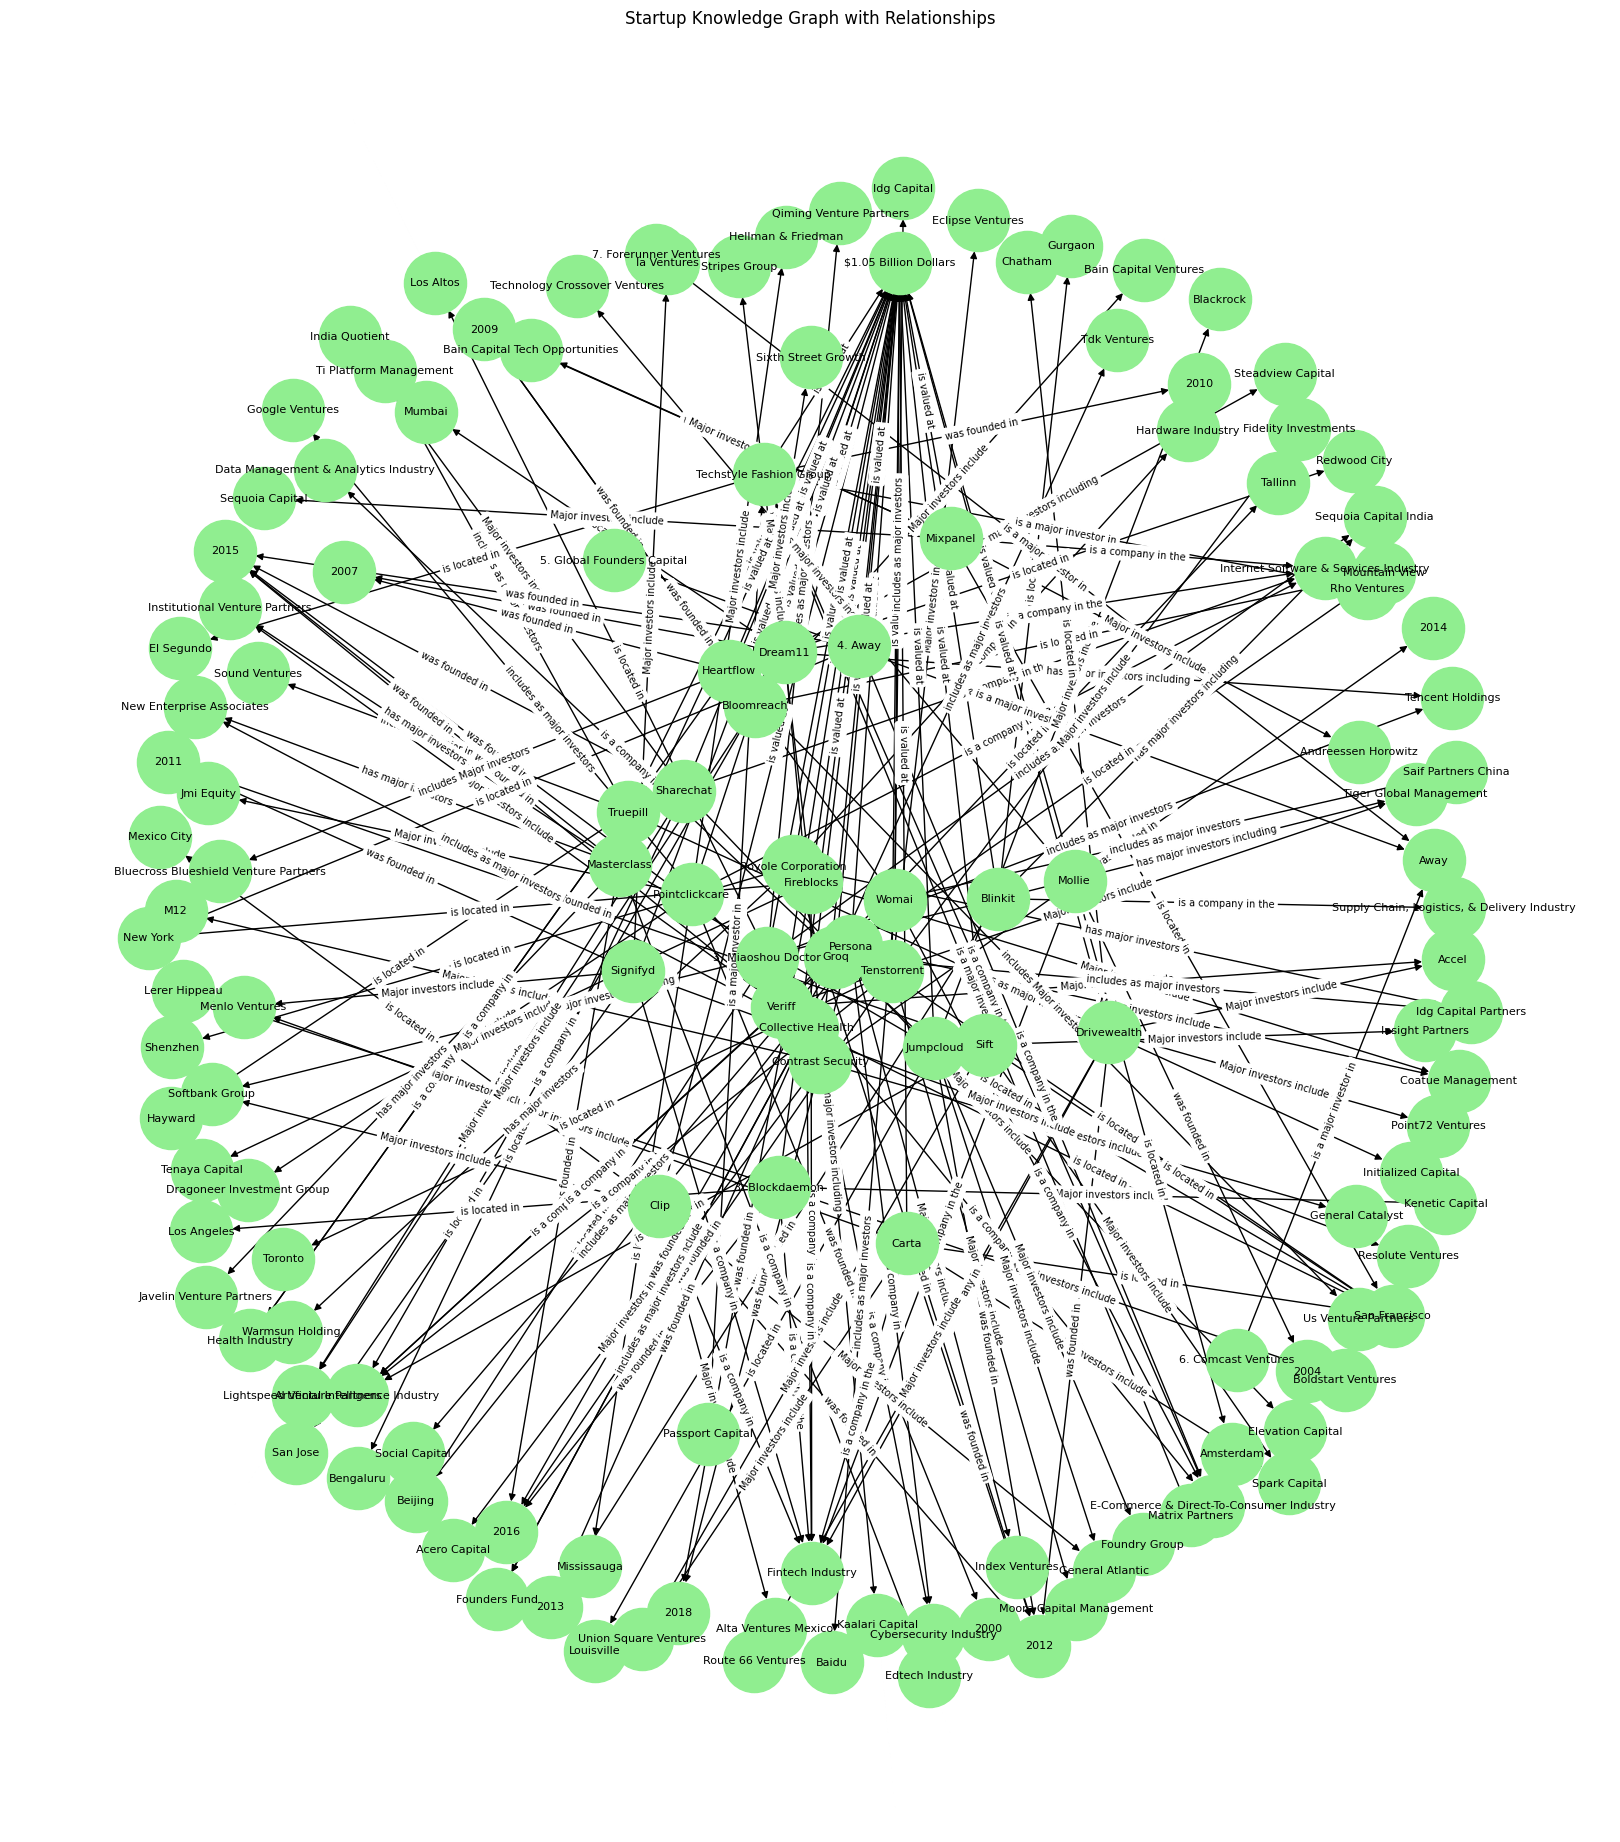

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
plt.figure(figsize=(16,18))

pos = nx.spring_layout(G, k=.81 ,seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightgreen",
    font_size=8
)

edge_labels = nx.get_edge_attributes(G, "relation")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Startup Knowledge Graph with Relationships")

plt.show()